Connected to geo_env (Python 3.11.9)

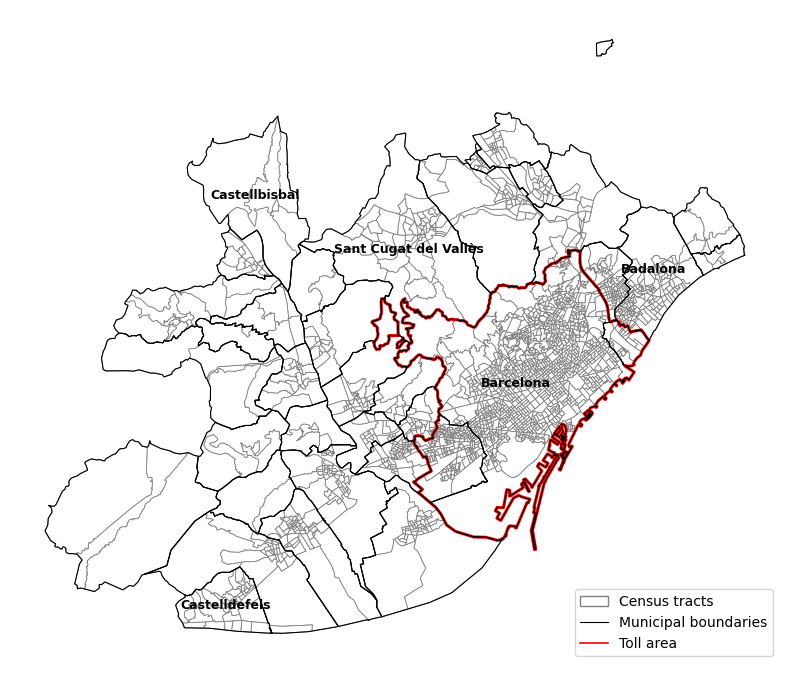

                            OLS Regression Results                            
Dep. Variable:                  log_h   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     329.2
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           2.37e-67
Time:                        18:31:17   Log-Likelihood:                -2167.1
No. Observations:                1688   AIC:                             4338.
Df Residuals:                    1686   BIC:                             4349.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3751      0.281    -19.105      0.0

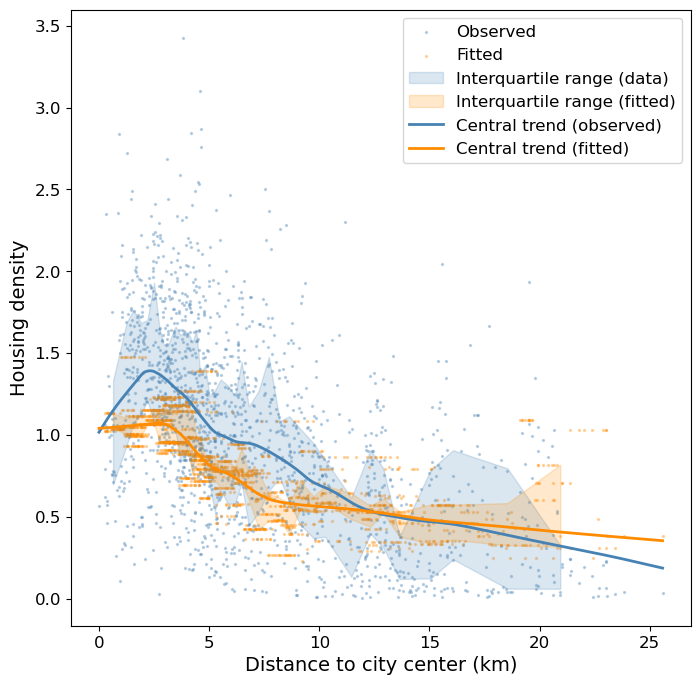

FIXED_COST_CAR:  163.85119678459876
LAMBDA:  272.85045079771686
x = [163.85119678459876, 272.85045079771686, 1217.5748616980418, 1083.6094638798108, 1176.4517573337816, 1142.7918454161056, 1102.9579083712485, 1145.5160295787182, 1070.111057128613, 1160.8579580086541, 2057.3274444773997, 1792.6485804185993, 1968.9531237696556, 1904.0895197540533, 1830.10677285325, 1902.8647626576849, 1776.0540519488338, 1934.2562402361564, 2835.835333759619, 2552.999484548188, 2735.2526741976535, 2658.626967458506, 2575.210341296344, 2656.8781823825516, 2527.99795270475, 2690.3119005765693]
error_mode_by_tract = 67797.57835579039
error_mode_AMB = 63.51372800231911
error_employment = 5674.442546782218
estimated_wage_LOW 1158.006708937057
estimated_wage_MED 1960.4500626284957
estimated_wage_HIGH 2733.863568125633
error_wage = 63.14796890900093
error_spatial_wage = 294.43739995133126
Modal share of public transport (%): 53
Modal share of public transport (%): 49
Modal share of public transport (%): 54
Moda

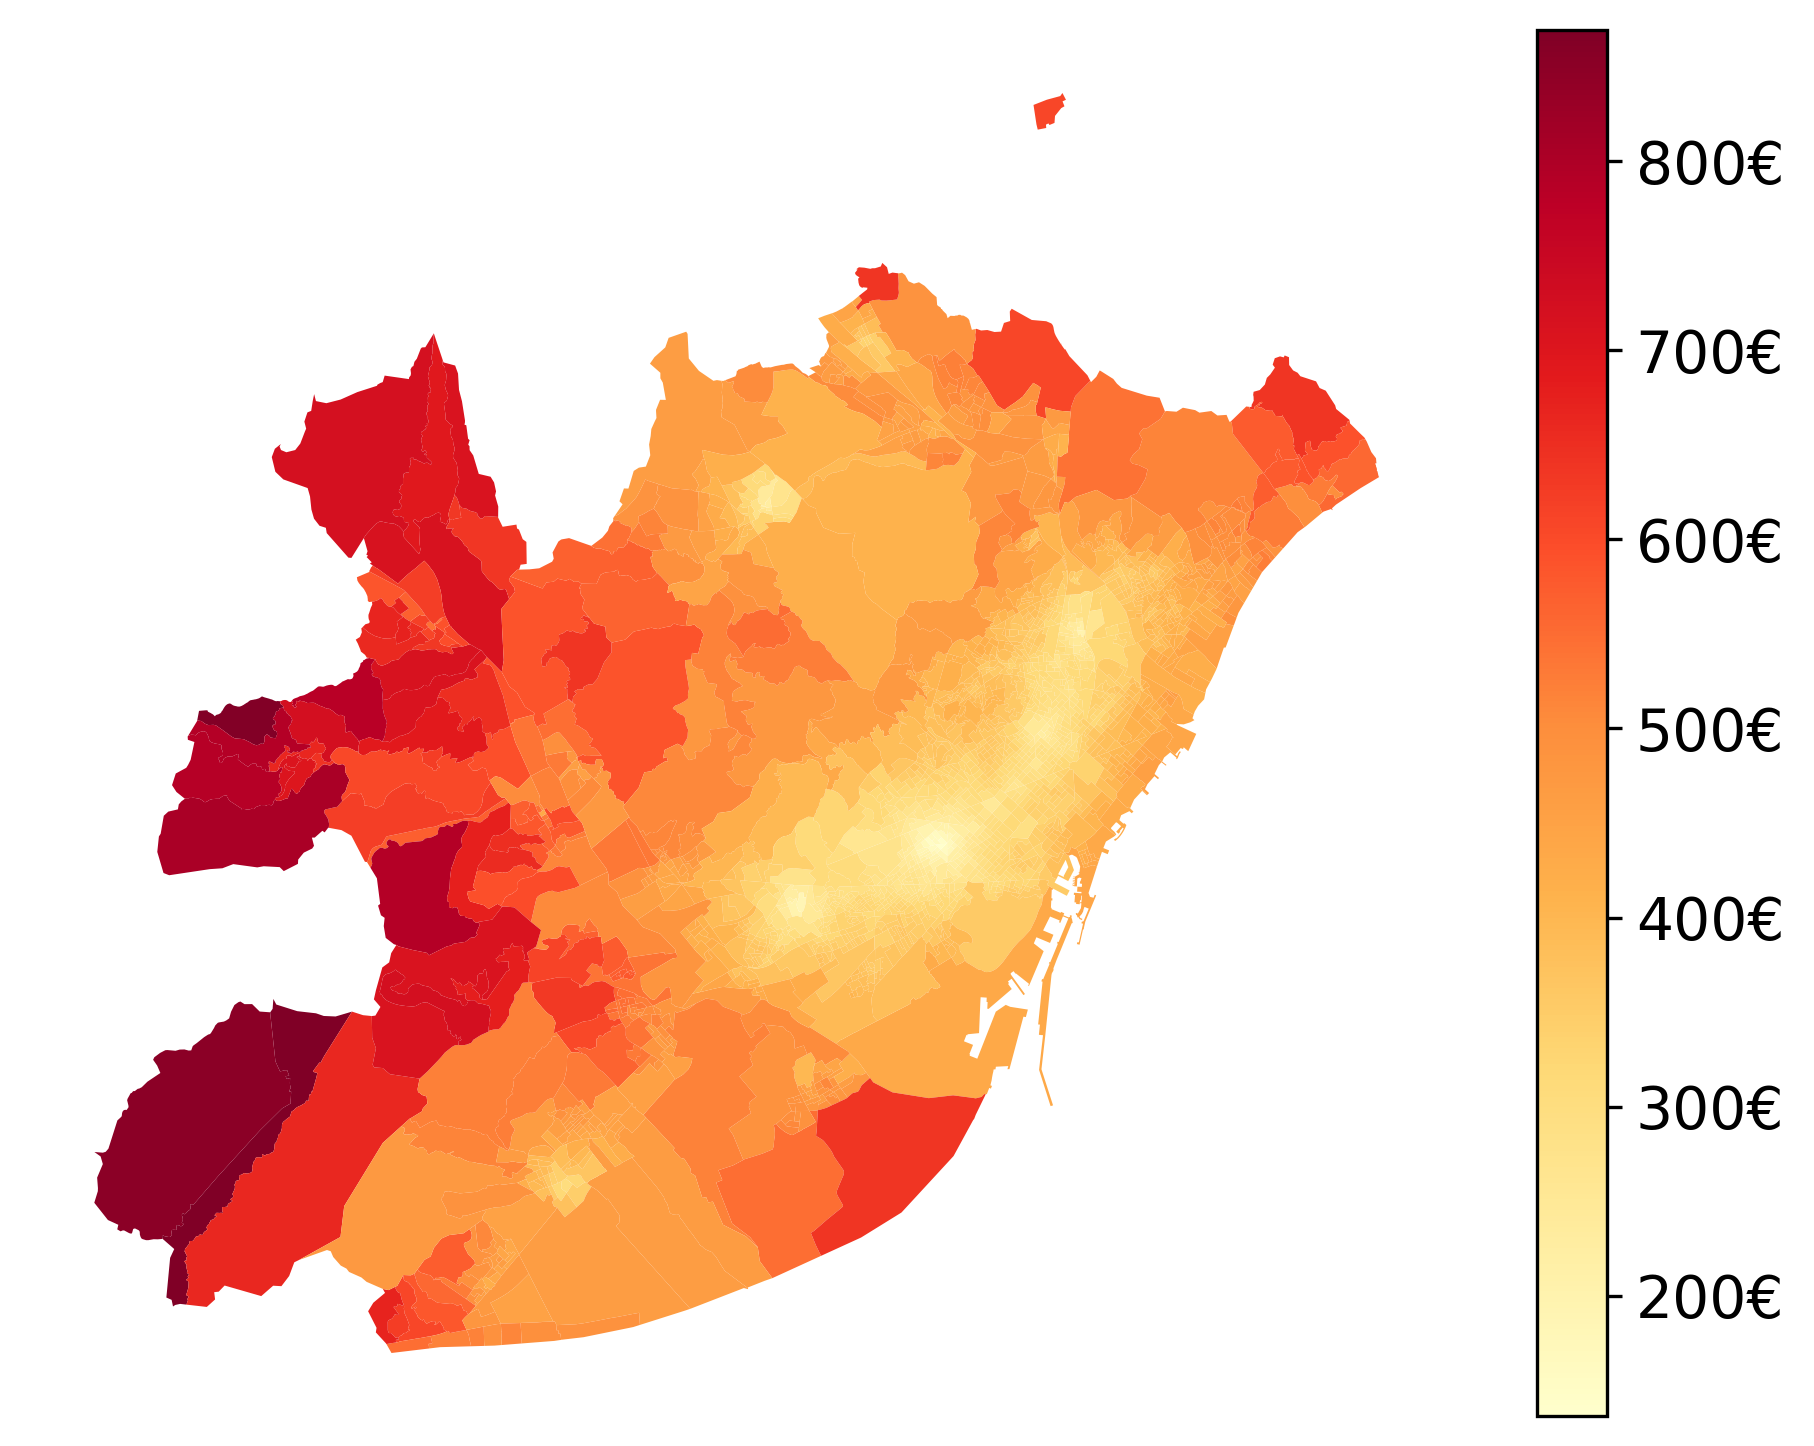

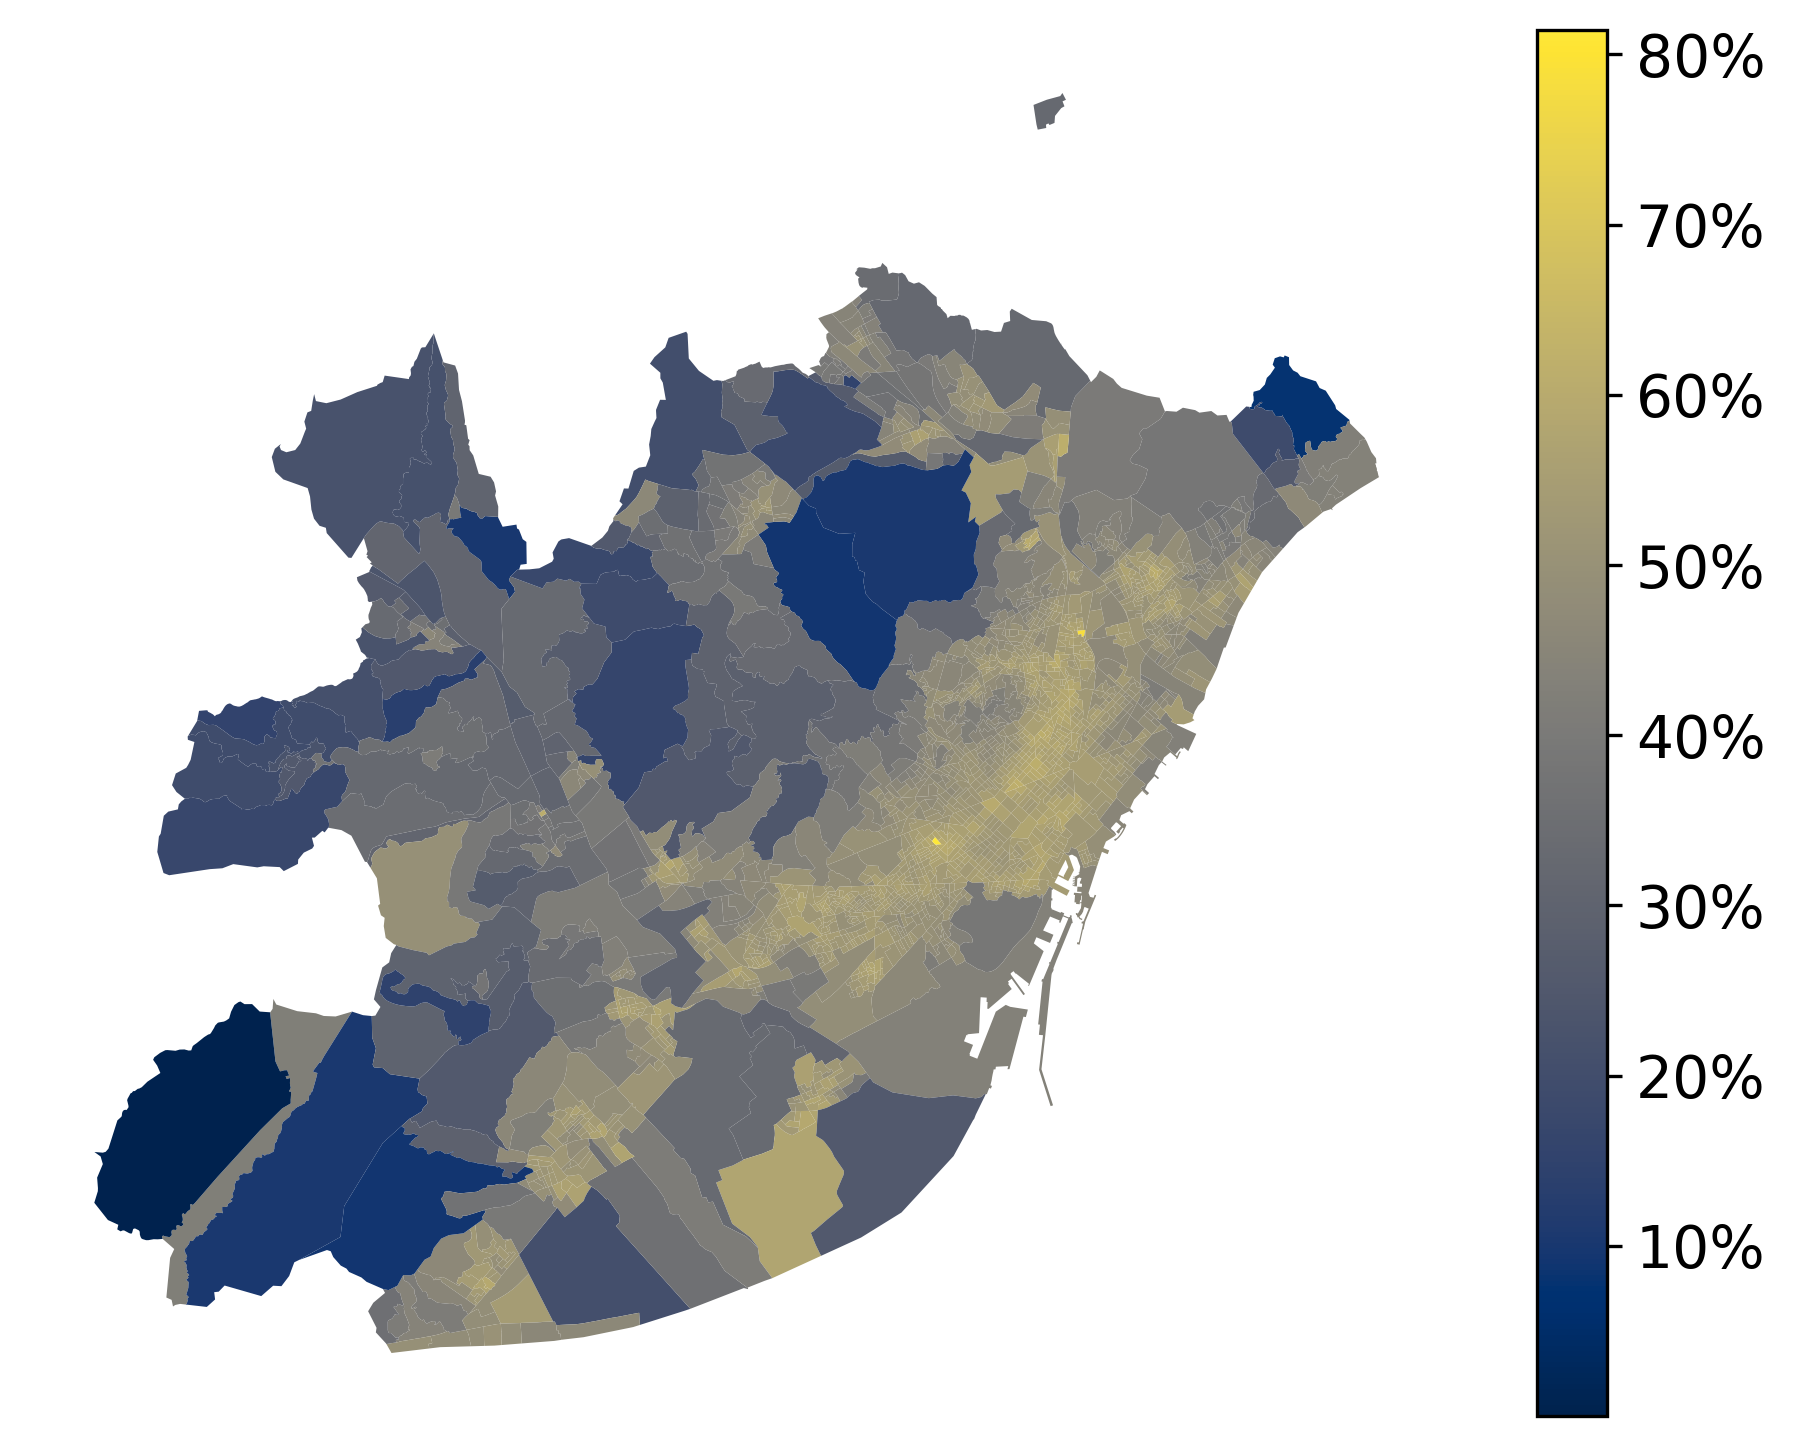

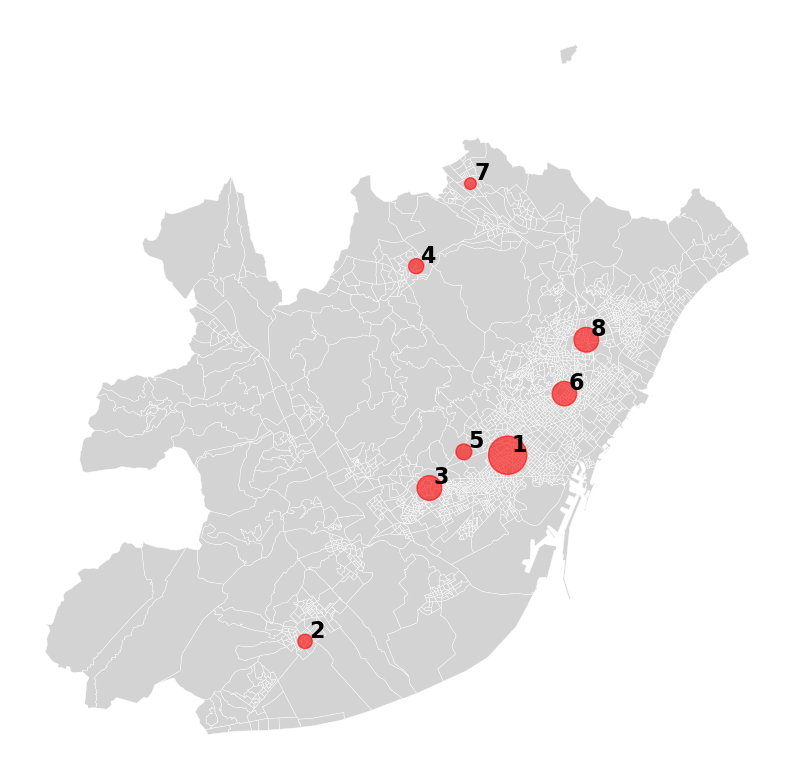

[3.00e-01 2.24e+02 3.86e+02 5.53e+02]
scoreDwellingSize: -1585.5987873606764
scoreAmenities: -3000.623031551355
log_sorting: -13543.229330712584
[3.0000001e-01 2.2400000e+02 3.8600000e+02 5.5300000e+02]
scoreDwellingSize: -1585.5986677546148
scoreAmenities: -3000.6230315513553
log_sorting: -13543.228915363099
[3.00e-01 2.24e+02 3.86e+02 5.53e+02]
scoreDwellingSize: -1585.598787397076
scoreAmenities: -3000.623031551355
log_sorting: -13543.22934076031
[3.00e-01 2.24e+02 3.86e+02 5.53e+02]
scoreDwellingSize: -1585.598787370558
scoreAmenities: -3000.6230315513553
log_sorting: -13543.229315733744
[3.00e-01 2.24e+02 3.86e+02 5.53e+02]
scoreDwellingSize: -1585.598787339035
scoreAmenities: -3000.623031551355
log_sorting: -13543.229337098004
[3.45944357e-01 2.23163818e+02 3.85772997e+02 5.53497150e+02]
scoreDwellingSize: -1033.8070729309693
scoreAmenities: -3000.623031551355
log_sorting: -11705.01331140291
[3.45944367e-01 2.23163818e+02 3.85772997e+02 5.53497150e+02]
scoreDwellingSize: -1033.80

In [ ]:
import numpy as np 
from copy import deepcopy
from scipy.sparse import csr_matrix # type: ignore
import pickle
import datetime

from outcomes import *
from ABM import *
from import_data import * # type: ignore
from calibration import * # type: ignore
from model import * # type: ignore
from plotting_tools import * # type: ignore
from import_transport import *
from policy_support import *

### SCENARIOS

scenario = "baseline"
option_center = "UEA" #test1, "catalunya"

#scenario = "exemption_trips_inside_zone"    #DONE
#scenario = "tax_question_P17"               #DONE
#scenario = "increasing_knowledge"           #DONE
#scenario = "instant_welfare_adjust"         #DONE
#scenario = "discount_low_income"            #DONE
#scenario = "discount_residents"             #DONE

#scenario = "less_expensive_transport"       #DONE
#scenario = "improve_rodalies"               #DONE
#scenario = "reduce_transport_time"          #DONE

### IMPORT PARAMETERS

path_data = "../data_barcelona/"
option_function = "Cobb-Douglas"

LOGISTIC_PARAM_WELFARE = -0.3
LOGISTIC_PARAM_QOL = 0.3

#Time
year = 0
MAX_YEAR = 20

#Policy impact model
INTEREST_RATE = 0.05
PRICE_TIME = 10 #euros/h - later modulated by income level
WORKING_DAYS = 40 #20 days per month, with 2 trips per day
PRICE_FUEL = 0.11 #euros/km
center = "0801901025"
SOFT_RENT = 50
DIFF_SPEED_CONGESTION = 10


#ABM
SCALE_ABM = 1/100 #Nb of agents in the ABM
PROBA_MOVE = 0.2
INERTIA_OPINION = 0.8 #inertia

### IMPORT DATA

#Import data
gdf = import_data(path_data, center, option = "SECTION") #"DISTRICT" or "SECTION" - Active population: 1.4M
gdf = import_jobs(gdf, path_data)
gdf = import_land_use(gdf, path_data)
gdf = import_ppl_per_hh(gdf, path_data)
gdf = import_rent_and_size(gdf, path_data)
Y_median, gdf = import_income_new(gdf, path_data)
gdf = import_amenities(gdf, path_data, 0, 0)
employment_centers = gpd.read_file(path_data + "cluster_employment_" + option_center + ".shp")
employment_centers["cluster"] = employment_centers.index
jobs_in_toll_area, houses_in_toll_area, zone_tax = import_tax_zone(gdf, employment_centers)
plot_base_map(gdf)

#Multiple income groups
income_levels = ["LOW", "MED", "HIGH"]
wage_factors = {"LOW": 0.6, "MED": 1.0, "HIGH": 1.4}
pop = {
    "LOW": np.nansum(gdf["pop"] * gdf["share_low_income"] / 100),
    "MED": np.nansum(gdf["pop"] * (100 - gdf["share_high_income"] - gdf["share_low_income"]) / 100),
    "HIGH": np.nansum(gdf["pop"] * gdf["share_high_income"] / 100),
}

#Prepare variables
gdf["size"] = gdf["size_census"] #gdf["size_census"] #gdf["size_AMB"]
gdf.loc[gdf["pop"] == 0, "pop"] = 1
gdf.loc[gdf["rent_m2"] == 0, "rent_m2"] = np.nanmin(gdf.loc[gdf["rent_m2"]>0, "rent_m2"])
gdf.loc[np.isnan(gdf["rent_m2"]), "rent_m2"] = np.nanmin(gdf.loc[gdf["rent_m2"]>0, "rent_m2"])
gdf.loc[np.isnan(gdf["size"]), "size"] = np.nansum(gdf.loc[~np.isnan(gdf["size"]), "size"] * gdf.loc[~np.isnan(gdf["size"]), "pop"]) / np.nansum(gdf.loc[~np.isnan(gdf["size"]), "pop"])

#Import transport data
#import_transport_times_poly(gdf, datetime.datetime(2025, 7, 15, 8, 0, 0), center, path_data, employment_centers, option_center) #datetime.datetime(2025, 7, 15, 8, 0, 0)
travel_time_matrix_car, travel_time_matrix_transit = load_transport_times_poly(gdf, path_data, center, option_center)
travel_time_matrix_car = load_distance_car_poly(travel_time_matrix_car, gdf, employment_centers, jobs_in_toll_area, houses_in_toll_area, zone_tax)
gdf = import_cost_transit(gdf)
travel_time_matrix_transit = travel_time_matrix_transit.merge(gdf[['ID', 'monthly_cost_transit']].rename(columns={'ID': 'from_id'}), on='from_id', how='left')

travel_time_matrix_car["uncongested_speed"] = (travel_time_matrix_car.distance_car / 1000) / (travel_time_matrix_car.travel_time / 60)
travel_time_matrix_car["speed"] = travel_time_matrix_car["uncongested_speed"] - DIFF_SPEED_CONGESTION
travel_time_matrix_car.loc[travel_time_matrix_car["speed"] < 10, "speed"] = 10
travel_time_matrix_car.travel_time = ((travel_time_matrix_car.distance_car / 1000) / travel_time_matrix_car["speed"]) * 60

### CALIBRATION POLICY SUPPORT

#BETA_OPINION, INITIAL_OPINION = import_opinion_parameters(path_data, scenario)
#BETA_PRICE, INITIAL_PRICE, INITIAL_CC, INITIAL_WELFARE, INITIAL_QOL, INITIAL_KNOWLEDGE = import_price_parameters(path_data, scenario)


### CALIBRATION POLICY IMPACT MODEL

#Calibration of B and KAPPA
gdf["land"] = gdf["urb_area"]

mask = ((gdf["rent_m2"] < 25) &(gdf["rent_m2"] > 7)&
        (gdf["pop"] > 484.0)&
        (~np.isnan(gdf["size"]))
        &(~np.isnan(gdf["pop"]))
        &((gdf["pop"] > 0))
        )

B, KAPPA, SIGMA = calibrate_b_kappa(gdf, mask, INTEREST_RATE, option_function, option_calib = "housing")

#Transport cost calibration
#gdf, FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH = compute_cost_car_poly_i(gdf, Y_median, import_trans_mode, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, travel_time_matrix_car, travel_time_matrix_transit, employment_centers, path_data, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, compute_error_transport_poly)
#with open(path_data + "calib_trans_poly_i" + option_center + ".pkl", "wb") as f: #UEA_v2
#    pickle.dump((FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH), f)
with open(path_data + "calib_trans_poly_i_" + option_center + ".pkl", "rb") as f:
    FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH = pickle.load(f)
print("FIXED_COST_CAR: ", FIXED_COST_CAR)
print("LAMBDA: ", LAMBDA)
compute_error_transport_poly([FIXED_COST_CAR, LAMBDA] + list(ARRAY_WAGE_LOW) + list(ARRAY_WAGE_MED) + list(ARRAY_WAGE_HIGH), employment_centers, gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, Y_median, import_trans_mode, path_data)
del compute_transport_cost_logit, compute_cost_car_logit

#Compute transport cost
gdf, workers_per_cluster, travel_matrix = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, scenario)
print("Modal share of public transport (%):", round(100 * sum(np.nansum(gdf[f"transport_mode_{lvl}"] * gdf[f"pop_{lvl}"]) for lvl in income_levels) / sum(np.nansum(gdf[f"pop_{lvl}"]) for lvl in income_levels)))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf["transport_mode_HIGH"] * gdf["pop_HIGH"])) / (np.nansum(gdf["pop_HIGH"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_MED"] * gdf[f"pop_MED"])) / (np.nansum(gdf[f"pop_MED"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_LOW"] * gdf[f"pop_LOW"])) / (np.nansum(gdf[f"pop_LOW"]))))
plot_transport_cost_i(gdf, "_HIGH")
plot_transport_mode_i(gdf, "_HIGH")
plot_employment(gdf, employment_centers, employment_centers['employment'] * 0.0015)

gdf["rodalies_500m_1km"] = ((gdf["min_distance_rodalies"] > 500) & (gdf["min_distance_rodalies"] < 1000)) * 1
gdf["fgc_500m_1km"] = ((gdf["min_distance_fgc"] > 500) & (gdf["min_distance_fgc"] < 1000)) * 1

#Calibrate beta and amenities
def compute_log_likelihood(x):
    print(x)
    return calibration_utility_amenity2(x, gdf, income_levels, SOFT_RENT, 0, 0)

calib_beta = scipy.optimize.minimize(compute_log_likelihood, [0.3, 224, 386, 553], bounds=[(0.2,0.5), (0,None), (0,None), (0,None)]) #[0.45, 100, 500, 900] #[0.3, 224, 386, 553]
BETA = calib_beta.x[0]
print("BETA:", BETA)
#gdf = gdf.drop(columns = "amenities")
amenities = calibration_utility_amenity2(calib_beta.x, gdf, income_levels, SOFT_RENT, 1, 1)
gdf = gdf.merge(amenities, on = "ID", how = "left")
gdf.loc[np.isnan(gdf["amenities"]), "amenities"] = 1

# Solve the model
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""

    return sum(compute_error_in_population(u, gdf["amenities"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, False, option_function)**2)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, [161, 287, 411], bounds=[(0,None), (0,None), (0,None)], method = "Powell") #np.array([399,690,995]) np.array([370,690,800]) #[180, 420, 600]
solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, solving_model.x, bounds=[(0,None), (0,None), (0,None)], method = "Nelder-Mead") #np.array([399,690,995]) np.array([370,690,800]) #[180, 420, 600]
print(solving_model)

In [ ]:
solving_model

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 17964.893260406472
             x: [ 1.613e+02  2.870e+02  4.105e+02]
           nit: 281
          nfev: 540
 final_simplex: (array([[ 1.613e+02,  2.870e+02,  4.105e+02],
                       [ 1.613e+02,  2.870e+02,  4.105e+02],
                       [ 1.613e+02,  2.870e+02,  4.105e+02],
                       [ 1.613e+02,  2.870e+02,  4.105e+02]]), array([ 1.796e+04,  1.796e+04,  1.796e+04,  1.796e+04]))

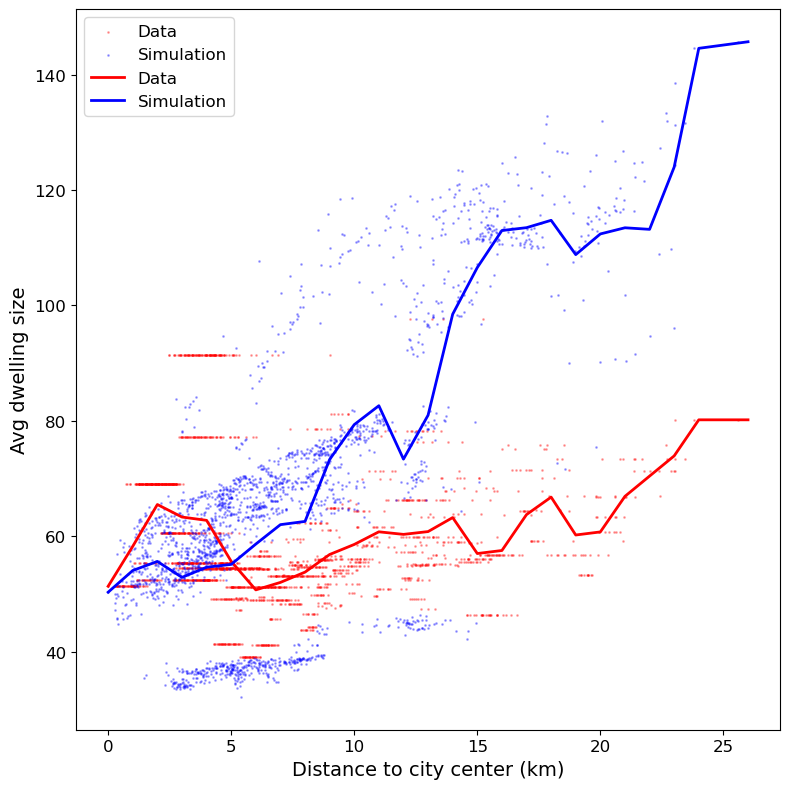

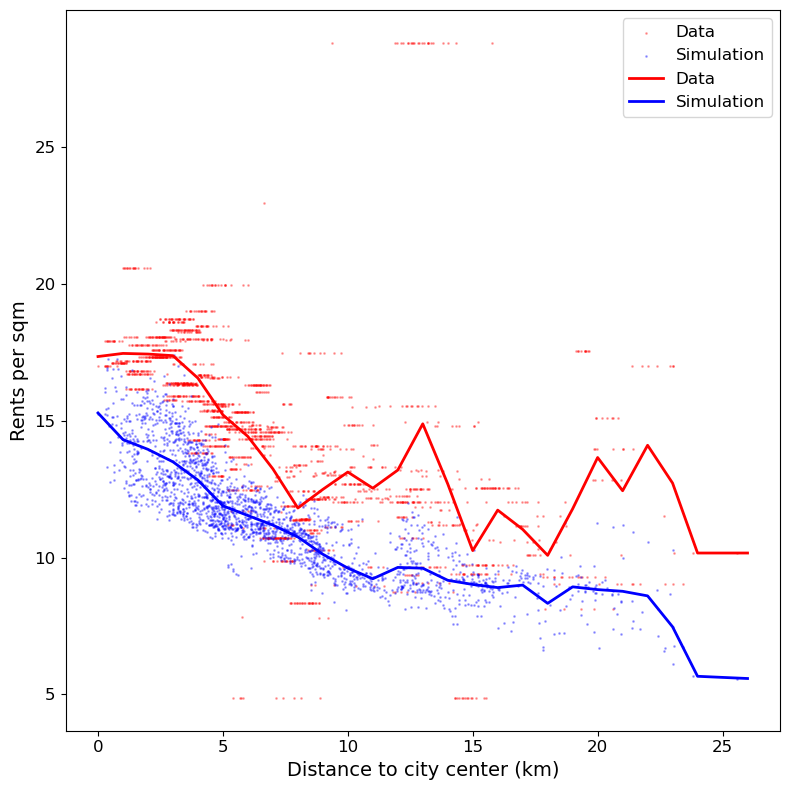

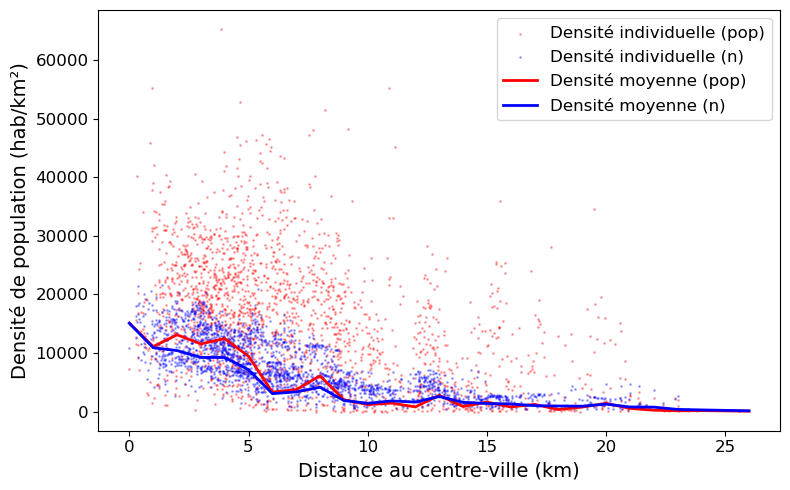

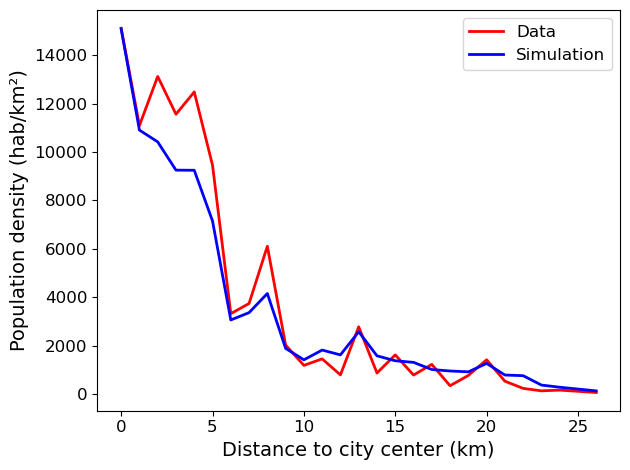

In [ ]:
if solving_model.fun < 20000:
    R, q, n, w, R_group, q_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, SIGMA, INTEREST_RATE, SOFT_RENT, income_levels, compute_rents, compute_dwelling_size, compute_population, option_function)
else:
    raise ValueError("Minimization failed!")

#share_col = {"LOW": "share_low_income", "MED": None, "HIGH": "share_high_income"}
#density_residual = {
#    lvl: np.log(
#        (gdf["pop"] * (gdf[share_col[lvl]] / 100 if share_col[lvl] else (100 - gdf["share_low_income"] - gdf["share_high_income"]) / 100))
#        / (w[lvl] * n)
#    )
#    for lvl in income_levels
#}
density_residual = np.log(gdf["pop"] / n)
rent_residual = np.log(gdf["rent_m2"] / R)
size_residual = np.log(gdf["size"] / q)

# Plot the result of the calibration
#print_maps(gdf, n, q, R)
plot_line_charts(gdf, n, q, R)

#initial state
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""

    return sum((compute_error_in_population(u, gdf["amenities"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, True, option_function, rent_residual, density_residual, size_residual))**2)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, [159.7, 283.9, 404.7], method = "Powell")

In [ ]:
solving_model

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 417860.7096783307
       x: [ 1.597e+02  2.839e+02  4.047e+02]
     nit: 4
   direc: [[ 1.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  1.000e+00]]
    nfev: 355

In [ ]:
if solving_model.fun < 500000:

    R, q, n, w, R_group, q_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, SIGMA, INTEREST_RATE, SOFT_RENT, income_levels, compute_rents, compute_dwelling_size, compute_population, option_function)

    R = R * np.exp(rent_residual)
    q = q * np.exp(size_residual)
    n_group = {lvl: n * w[lvl] * np.exp(density_residual[lvl]) for lvl in ["LOW", "MED", "HIGH"]}
    n = np.nansum(list(n_group.values()), axis=0)
    n[np.isnan(n)] = 0
    for lvl in income_levels:
        n_group[lvl][np.isnan(n_group[lvl])] = 0

else:
    raise ValueError("Minimization failed!")

plot_line_charts(gdf, n, q, R)

# ABM: translate outputs at the household level
N = {lvl: round(pop[lvl] * SCALE_ABM) for lvl in income_levels}
#support = {lvl: INITIAL_OPINION * np.ones(N[lvl]) for lvl in income_levels}
indiv_loc_matrix = {
    lvl: compute_indiv_loc_matrix2(
        N[lvl], len(gdf), (n_group[lvl] * SCALE_ABM).to_numpy()
    )
    for lvl in income_levels
}

rent_indiv = {lvl: indiv_loc_matrix[lvl] @ R_group[lvl].to_numpy() for lvl in income_levels}
dwelling_size_indiv = {lvl: indiv_loc_matrix[lvl] @ q_group[lvl] for lvl in income_levels}

utility = {}

for lvl in income_levels:
    u = compute_utility_manually(
        indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"],
        indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"],
        dwelling_size_indiv[lvl],
        rent_indiv[lvl],
        BETA, indiv_loc_matrix[lvl] @ gdf["amenities"]
    )
    u[np.isnan(u)] = 0
    utility[lvl] = u

housing_indiv = {
    lvl: dwelling_size_indiv[lvl] @ csr_matrix(indiv_loc_matrix[lvl])
    for lvl in income_levels
}

# Save outputs
save_housing = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
save_rent = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_dwelling_size = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_transport_mode = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_utility = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}

for lvl in income_levels:
    save_housing[lvl][:, 0] = deepcopy(housing_indiv[lvl])
    save_rent[lvl][:, 0] = deepcopy(rent_indiv[lvl])
    save_dwelling_size[lvl][:, 0] = deepcopy(dwelling_size_indiv[lvl])
    save_transport_mode[lvl][:, 0] = deepcopy(indiv_loc_matrix[lvl] @ gdf[f"transport_mode_{lvl}"])
    save_utility[lvl][:, 0] = deepcopy(utility[lvl])

save_population = np.zeros((len(gdf), MAX_YEAR))
save_population[:, 0] = np.sum([np.nansum(indiv_loc_matrix[lvl], 0) for lvl in income_levels], axis=0)
save_population_lvl = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
for lvl in income_levels:
    save_population_lvl[lvl][:, 0] = np.nansum(indiv_loc_matrix[lvl], 0)

save_tax = np.zeros(MAX_YEAR)
save_tax[0] = 0
save_emissions = np.zeros(MAX_YEAR)
save_score_welfare = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_qol = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_congestion = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_median_support = np.zeros(MAX_YEAR)
qol_in_zone = np.zeros(MAX_YEAR)
qol_out_zone = np.zeros(MAX_YEAR)
vkm_in_zone = np.zeros(MAX_YEAR)
vkm_out_zone = np.zeros(MAX_YEAR)
total_vkm = np.zeros(MAX_YEAR)
total_vkm_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_in_zone_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_out_zone_lvl = np.empty(MAX_YEAR, dtype=object)
mode_shares_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_in_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_out_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_in_toll_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_wage_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_tcost_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_rent_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_dsize_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}

tax_revenues = np.zeros(MAX_YEAR)

save_emissions[0], total_vkm[0], tax_revenues[0], _, _, total_vkm_lvl[0] = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, 0, WORKING_DAYS, 0, SCALE_ABM)
qol_in_zone[0], qol_out_zone[0], vkm_in_zone[0], vkm_out_zone[0], vkm_in_zone_lvl[0], vkm_out_zone_lvl[0] = compute_qol_congestion(gdf, travel_matrix, indiv_loc_matrix, income_levels)

### DECOMPOSITION TRANSPORT

gdf["live_in_toll"] = (gdf.ID.isin(houses_in_toll_area))
for lvl in income_levels:
    s = (travel_matrix.loc[travel_matrix.to_id.isin(jobs_in_toll_area),
                      ["from_id", f"proba_center_{lvl}"]].groupby("from_id")[f"proba_center_{lvl}"].sum())
    gdf = gdf.merge(s, left_on="ID", right_on="from_id", how="left").rename(columns={f"proba_center_{lvl}": f"work_in_toll_{lvl}"}).fillna(0)

for lvl in income_levels:
    #mode share
    mode_shares_lvl[lvl][0] = np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)) / np.nansum(np.nansum(indiv_loc_matrix[lvl], 0))
    #distances
    avg_vkm_lvl[lvl][0] = (total_vkm_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0))))
    avg_vkm_in_zone_lvl[lvl][0] = vkm_in_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    avg_vkm_out_zone_lvl[lvl][0] = vkm_out_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    #repartition
    gdf[f"live_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == True) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_out_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == False) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_in_toll_and_work_out_{lvl}"] = (gdf["live_in_toll"] == True) * (1 - gdf[f"work_in_toll_{lvl}"])
    gdf[f"live_out_and_work_out_toll_{lvl}"] = (gdf["live_in_toll"] == False) * (1 - gdf[f"work_in_toll_{lvl}"])
    live_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_and_work_in_toll_{lvl}"]) / N[lvl]
    live_out_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_in_toll_{lvl}"]) / N[lvl]
    live_in_toll_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_in_toll_and_work_out_{lvl}"]) / N[lvl]
    live_out_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_out_toll_{lvl}"]) / N[lvl]
    #decompo util
    avg_wage_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"])
    avg_tcost_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"])
    avg_rent_lvl[lvl][0] = np.nanmean(rent_indiv[lvl])
    avg_dsize_lvl[lvl][0] = np.nanmean(dwelling_size_indiv[lvl])
BETA_CONG = DIFF_SPEED_CONGESTION/total_vkm[0]

year = year + 1
#plot_distance_distrib_check(income_levels, travel_matrix, "HIGH")

tax_revenue_here = 137000000
subvention_here = 137000000
efficiency = 0
discount = 12.79346
time_discount = 0

### FIRST SIMULATION TO COMPUTE UTILITY LOSSES

gdf_init, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, "baseline", 0, 0)
 
utility_init = {lvl: compute_utility_manually(gdf_init[f"wage_{lvl}"],
                                              gdf_init[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

gdf_tax, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0.5, income_levels, wage_factors, "baseline", 0, 0)
 
utility_tax = {lvl: compute_utility_manually(gdf_tax[f"wage_{lvl}"],
                                              gdf_tax[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

for lvl in income_levels:
    gdf[f"score_welfare_{lvl.lower()}"] = compute_score(compute_change_in_welfare(utility_init[lvl], utility_tax[lvl]), LOGISTIC_PARAM_WELFARE)

expected_welfare_loss = gdf[["ID", "geometry"] + [f"score_welfare_{lvl.lower()}" for lvl in income_levels]]

### CALIBRATION POLICY SUPPORT

BETA_OPINION, BETA_PRICE, INITIAL_OPINION, INITIAL_PRICE, INITIAL_CC, INITIAL_WELFARE, INITIAL_QOL, INITIAL_KNOWLEDGE = import_opinion_parameters2(path_data, scenario, expected_welfare_loss)

tax = INITIAL_PRICE
acceptable_price = {"LOW": INITIAL_PRICE, "MED": INITIAL_PRICE, "HIGH": INITIAL_PRICE}
#support = {"LOW": INITIAL_OPINION, "MED": INITIAL_OPINION, "HIGH": INITIAL_OPINION}
save_score_emissions = np.zeros(MAX_YEAR)
save_score_emissions[0] = INITIAL_CC
save_knowledge = np.zeros(MAX_YEAR)
save_knowledge[0] = INITIAL_KNOWLEDGE
score_qol = {"LOW": INITIAL_QOL, "MED": INITIAL_QOL, "HIGH": INITIAL_QOL}
score_welfare = {"LOW": INITIAL_WELFARE, "MED": INITIAL_WELFARE, "HIGH": INITIAL_WELFARE}
support = {lvl: INITIAL_OPINION * np.ones(N[lvl]) for lvl in income_levels}

### MODELING THE PSC

KeyError: 'LOW'

In [ ]:
n_group = {lvl: n * w[lvl] * np.exp(density_residual) for lvl in ["LOW", "MED", "HIGH"]}
n = np.nansum(list(n_group.values()), axis=0)
n[np.isnan(n)] = 0
for lvl in income_levels:
    n_group[lvl][np.isnan(n_group[lvl])] = 0

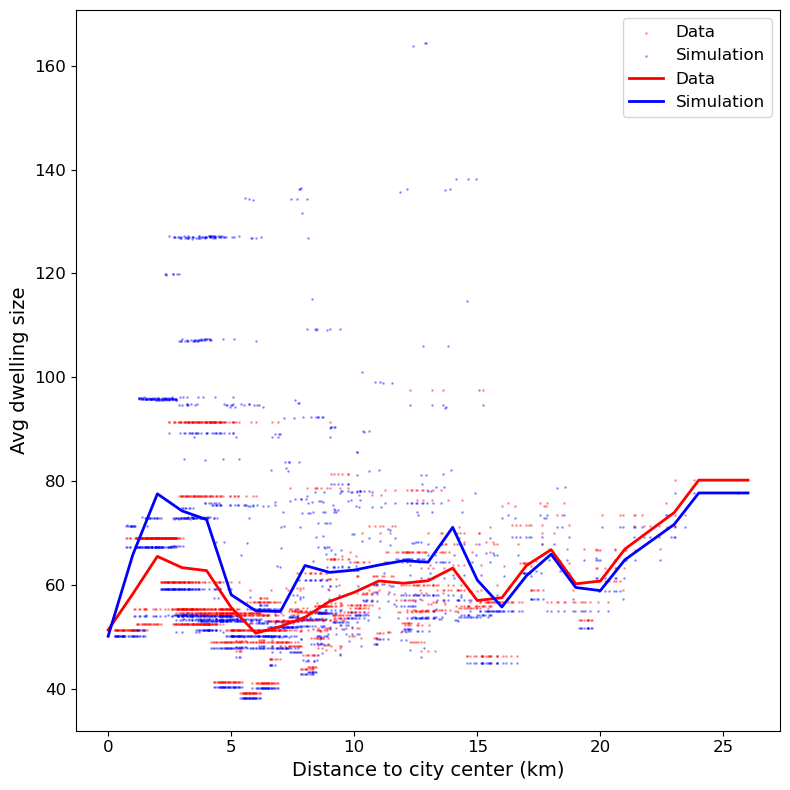

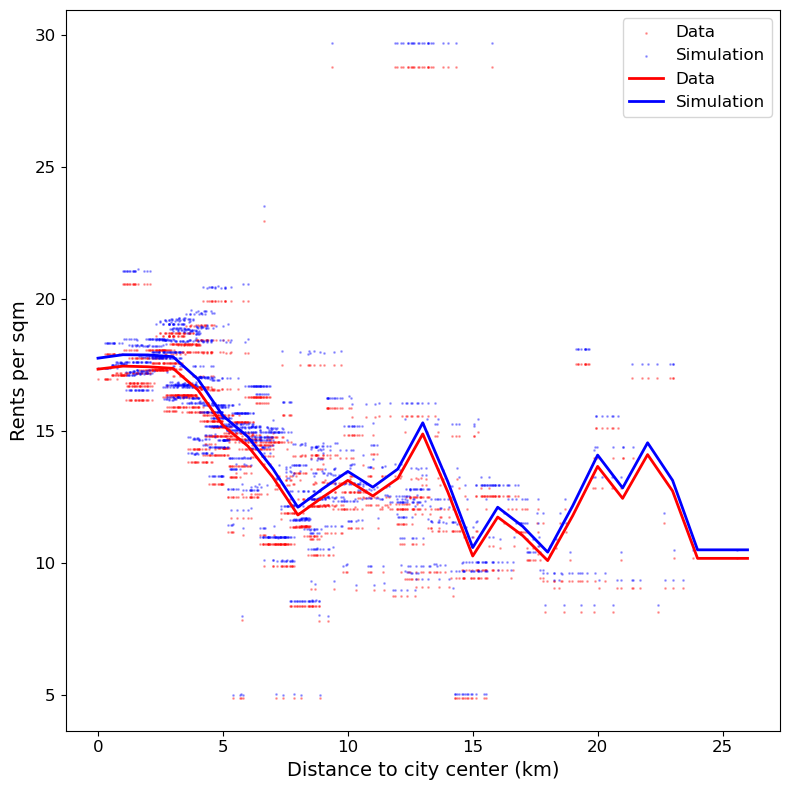

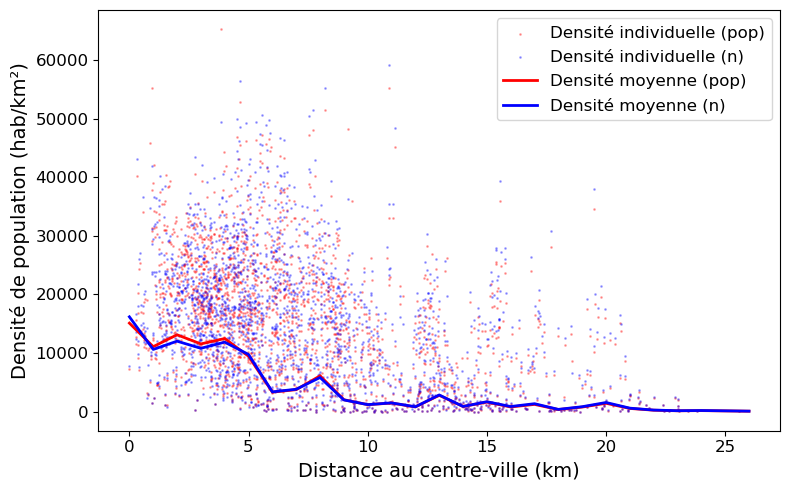

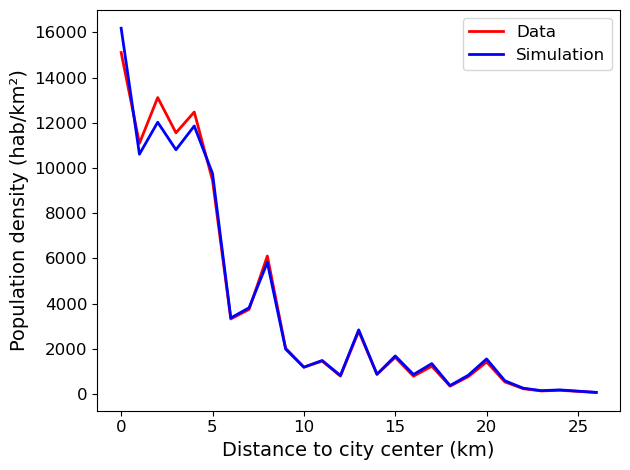

SignificanceResult(statistic=0.6035851309092074, pvalue=3.229002034877782e-98)


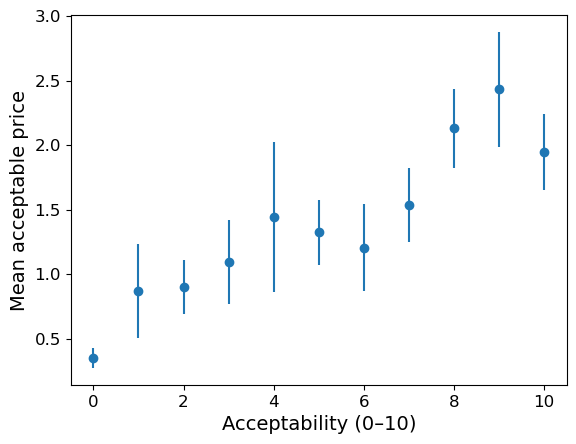

c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:312: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:312: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


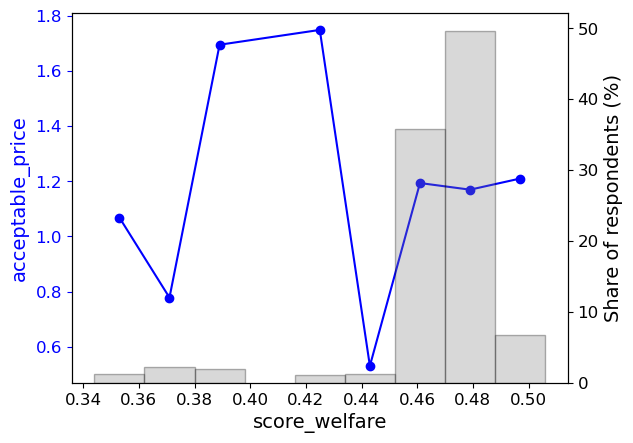

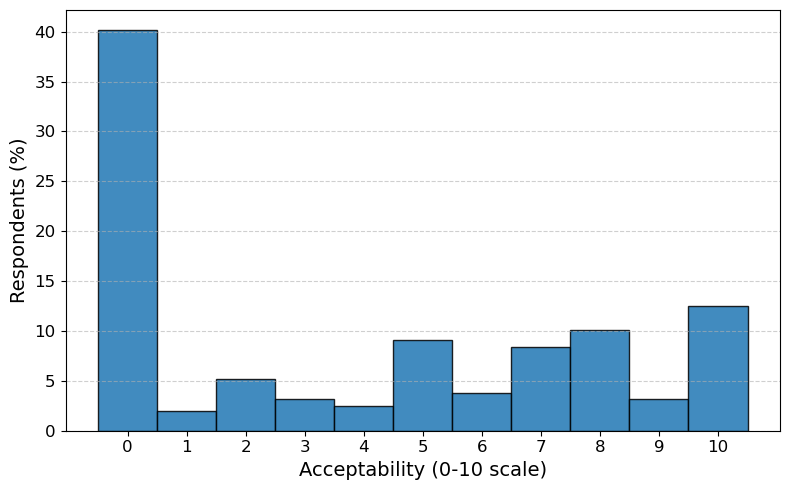

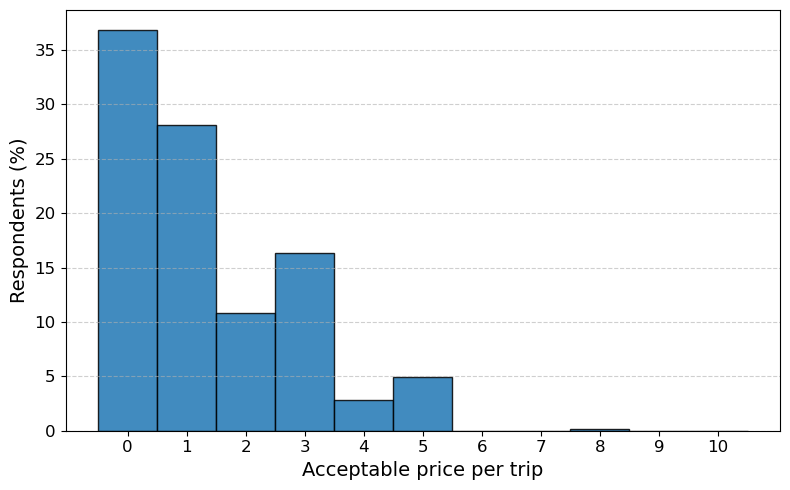

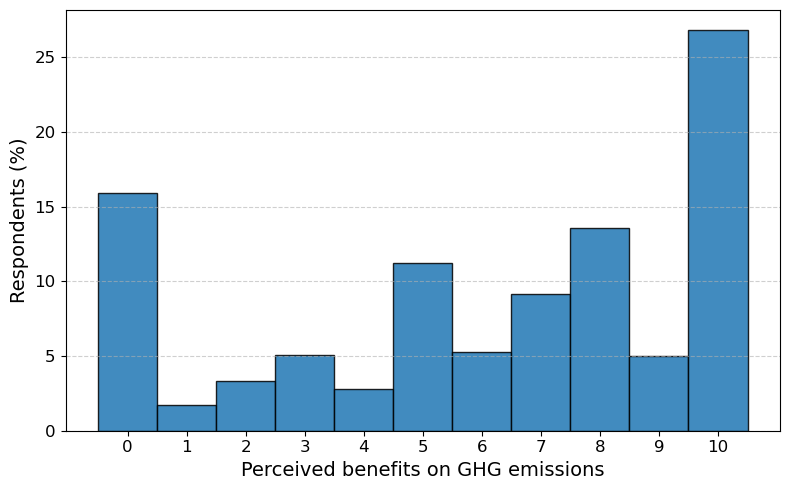

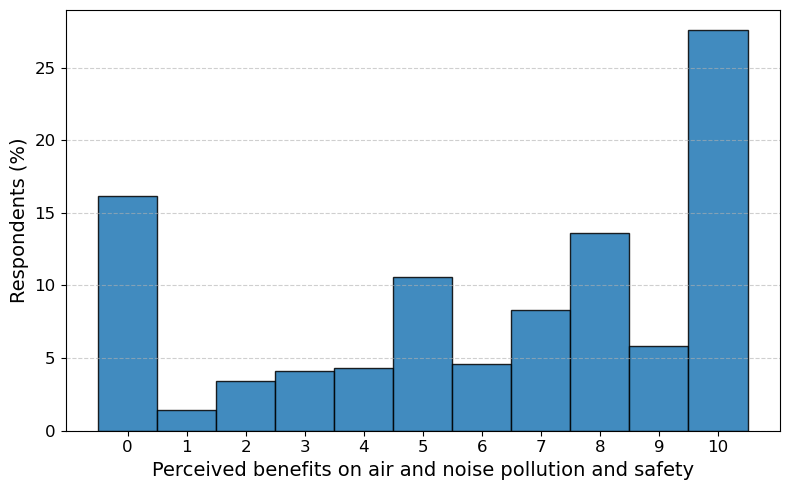

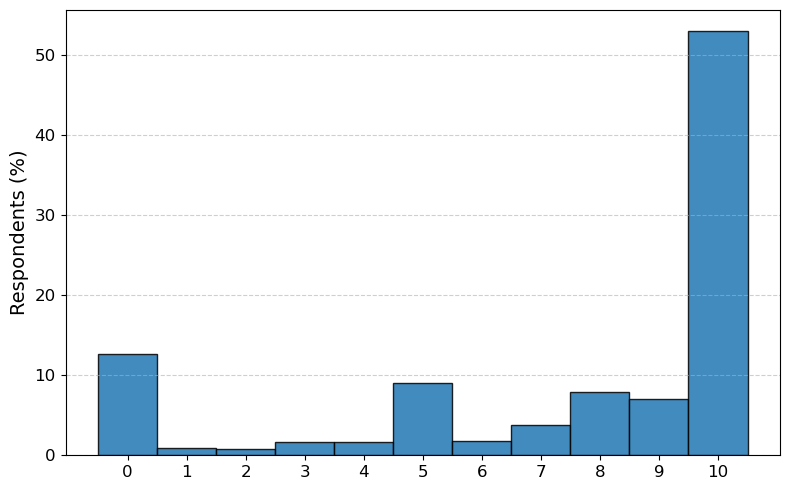

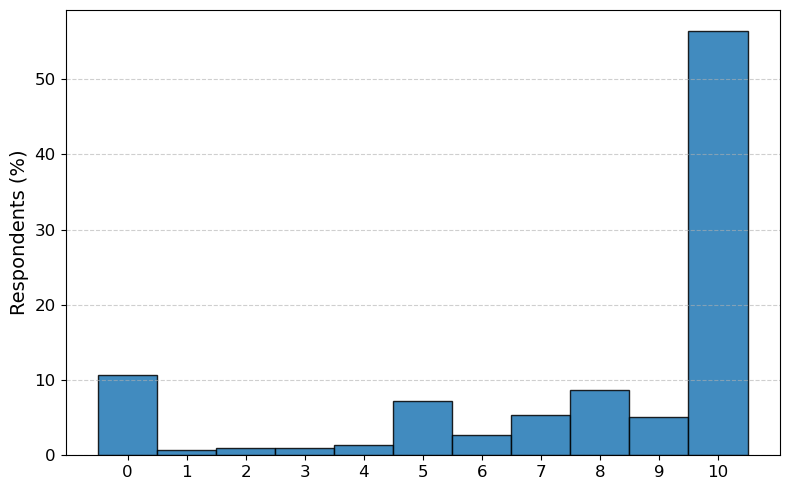

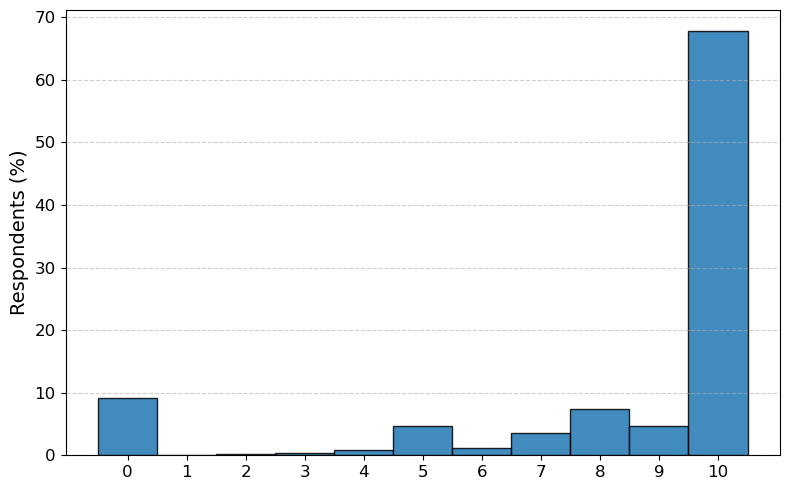

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.423
Model:                            WLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     139.3
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          7.82e-111
Time:                        18:56:37   Log-Likelihood:                -259.46
No. Observations:                 955   AIC:                             530.9
Df Residuals:                     949   BIC:                             560.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [ ]:
plot_line_charts(gdf, n, q, R)

# ABM: translate outputs at the household level
N = {lvl: round(pop[lvl] * SCALE_ABM) for lvl in income_levels}
#support = {lvl: INITIAL_OPINION * np.ones(N[lvl]) for lvl in income_levels}
indiv_loc_matrix = {
    lvl: compute_indiv_loc_matrix2(
        N[lvl], len(gdf), (n_group[lvl] * SCALE_ABM).to_numpy()
    )
    for lvl in income_levels
}

rent_indiv = {lvl: indiv_loc_matrix[lvl] @ R_group[lvl].to_numpy() for lvl in income_levels}
dwelling_size_indiv = {lvl: indiv_loc_matrix[lvl] @ q_group[lvl] for lvl in income_levels}

utility = {}

for lvl in income_levels:
    u = compute_utility_manually(
        indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"],
        indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"],
        dwelling_size_indiv[lvl],
        rent_indiv[lvl],
        BETA, indiv_loc_matrix[lvl] @ gdf["amenities"]
    )
    u[np.isnan(u)] = 0
    utility[lvl] = u

housing_indiv = {
    lvl: dwelling_size_indiv[lvl] @ csr_matrix(indiv_loc_matrix[lvl])
    for lvl in income_levels
}

# Save outputs
save_housing = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
save_rent = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_dwelling_size = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_transport_mode = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_utility = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}

for lvl in income_levels:
    save_housing[lvl][:, 0] = deepcopy(housing_indiv[lvl])
    save_rent[lvl][:, 0] = deepcopy(rent_indiv[lvl])
    save_dwelling_size[lvl][:, 0] = deepcopy(dwelling_size_indiv[lvl])
    save_transport_mode[lvl][:, 0] = deepcopy(indiv_loc_matrix[lvl] @ gdf[f"transport_mode_{lvl}"])
    save_utility[lvl][:, 0] = deepcopy(utility[lvl])

save_population = np.zeros((len(gdf), MAX_YEAR))
save_population[:, 0] = np.sum([np.nansum(indiv_loc_matrix[lvl], 0) for lvl in income_levels], axis=0)
save_population_lvl = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
for lvl in income_levels:
    save_population_lvl[lvl][:, 0] = np.nansum(indiv_loc_matrix[lvl], 0)

save_tax = np.zeros(MAX_YEAR)
save_tax[0] = 0
save_emissions = np.zeros(MAX_YEAR)
save_score_welfare = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_qol = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_congestion = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_median_support = np.zeros(MAX_YEAR)
qol_in_zone = np.zeros(MAX_YEAR)
qol_out_zone = np.zeros(MAX_YEAR)
vkm_in_zone = np.zeros(MAX_YEAR)
vkm_out_zone = np.zeros(MAX_YEAR)
total_vkm = np.zeros(MAX_YEAR)
total_vkm_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_in_zone_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_out_zone_lvl = np.empty(MAX_YEAR, dtype=object)
mode_shares_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_in_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_out_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_in_toll_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_wage_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_tcost_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_rent_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_dsize_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}

tax_revenues = np.zeros(MAX_YEAR)

save_emissions[0], total_vkm[0], tax_revenues[0], _, _, total_vkm_lvl[0] = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, 0, WORKING_DAYS, 0, SCALE_ABM)
qol_in_zone[0], qol_out_zone[0], vkm_in_zone[0], vkm_out_zone[0], vkm_in_zone_lvl[0], vkm_out_zone_lvl[0] = compute_qol_congestion(gdf, travel_matrix, indiv_loc_matrix, income_levels)

### DECOMPOSITION TRANSPORT

gdf["live_in_toll"] = (gdf.ID.isin(houses_in_toll_area))
for lvl in income_levels:
    s = (travel_matrix.loc[travel_matrix.to_id.isin(jobs_in_toll_area),
                      ["from_id", f"proba_center_{lvl}"]].groupby("from_id")[f"proba_center_{lvl}"].sum())
    gdf = gdf.merge(s, left_on="ID", right_on="from_id", how="left").rename(columns={f"proba_center_{lvl}": f"work_in_toll_{lvl}"}).fillna(0)

for lvl in income_levels:
    #mode share
    mode_shares_lvl[lvl][0] = np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)) / np.nansum(np.nansum(indiv_loc_matrix[lvl], 0))
    #distances
    avg_vkm_lvl[lvl][0] = (total_vkm_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0))))
    avg_vkm_in_zone_lvl[lvl][0] = vkm_in_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    avg_vkm_out_zone_lvl[lvl][0] = vkm_out_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    #repartition
    gdf[f"live_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == True) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_out_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == False) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_in_toll_and_work_out_{lvl}"] = (gdf["live_in_toll"] == True) * (1 - gdf[f"work_in_toll_{lvl}"])
    gdf[f"live_out_and_work_out_toll_{lvl}"] = (gdf["live_in_toll"] == False) * (1 - gdf[f"work_in_toll_{lvl}"])
    live_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_and_work_in_toll_{lvl}"]) / N[lvl]
    live_out_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_in_toll_{lvl}"]) / N[lvl]
    live_in_toll_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_in_toll_and_work_out_{lvl}"]) / N[lvl]
    live_out_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_out_toll_{lvl}"]) / N[lvl]
    #decompo util
    avg_wage_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"])
    avg_tcost_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"])
    avg_rent_lvl[lvl][0] = np.nanmean(rent_indiv[lvl])
    avg_dsize_lvl[lvl][0] = np.nanmean(dwelling_size_indiv[lvl])
BETA_CONG = DIFF_SPEED_CONGESTION/total_vkm[0]

year = year + 1
#plot_distance_distrib_check(income_levels, travel_matrix, "HIGH")

tax_revenue_here = 137000000
subvention_here = 137000000
efficiency = 0
discount = 12.79346
time_discount = 0

### FIRST SIMULATION TO COMPUTE UTILITY LOSSES

gdf_init, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, "baseline", 0, 0)
 
utility_init = {lvl: compute_utility_manually(gdf_init[f"wage_{lvl}"],
                                              gdf_init[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

gdf_tax, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0.5, income_levels, wage_factors, "baseline", 0, 0)
 
utility_tax = {lvl: compute_utility_manually(gdf_tax[f"wage_{lvl}"],
                                              gdf_tax[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

for lvl in income_levels:
    gdf[f"score_welfare_{lvl.lower()}"] = compute_score(compute_change_in_welfare(utility_init[lvl], utility_tax[lvl]), LOGISTIC_PARAM_WELFARE)

expected_welfare_loss = gdf[["ID", "geometry"] + [f"score_welfare_{lvl.lower()}" for lvl in income_levels]]

### CALIBRATION POLICY SUPPORT

BETA_OPINION, BETA_PRICE, INITIAL_OPINION, INITIAL_PRICE, INITIAL_CC, INITIAL_WELFARE, INITIAL_QOL, INITIAL_KNOWLEDGE = import_opinion_parameters2(path_data, scenario, expected_welfare_loss)

tax = INITIAL_PRICE
acceptable_price = {"LOW": INITIAL_PRICE, "MED": INITIAL_PRICE, "HIGH": INITIAL_PRICE}
#support = {"LOW": INITIAL_OPINION, "MED": INITIAL_OPINION, "HIGH": INITIAL_OPINION}
save_score_emissions = np.zeros(MAX_YEAR)
save_score_emissions[0] = INITIAL_CC
save_knowledge = np.zeros(MAX_YEAR)
save_knowledge[0] = INITIAL_KNOWLEDGE
score_qol = {"LOW": INITIAL_QOL, "MED": INITIAL_QOL, "HIGH": INITIAL_QOL}
score_welfare = {"LOW": INITIAL_WELFARE, "MED": INITIAL_WELFARE, "HIGH": INITIAL_WELFARE}
support = {lvl: INITIAL_OPINION * np.ones(N[lvl]) for lvl in income_levels}

### MODELING THE PSC

In [ ]:
while year < MAX_YEAR:

    print("YEAR", year)

    if ((scenario == "improved_rodalies") & (year == 6)):
        gdf = gdf.drop(columns = "amenities")

    save_knowledge[year] = save_knowledge[year-1] + 0.02

    # Urban form with the tax, without inertia
    
    TRIP_TO_ZONE_OUTPUT = total_vkm[year - 1]
    TRIP_TO_ZONE_INPUT = 0
    index_q = 0

    condition = True

    while condition == True:

        print("DISCOUNT", discount)
        print("DIFF SUBVENTION TAX REVENUE", subvention_here-tax_revenue_here)

        if scenario == "less_expensive_transport":
            discount = discount - (subvention_here-tax_revenue_here)/10000000
            time_discount = 0
        elif scenario == "reduce_transport_time":
            time_discount = time_discount + ((efficiency - 73) / 5000)
            discount = 0
        else:
            discount = 0
            time_discount = 0
        
        TRIP_TO_ZONE_INPUT = TRIP_TO_ZONE_OUTPUT.copy()
        index_q = index_q + 1
        travel_time_matrix_car["speed"] = travel_time_matrix_car["uncongested_speed"] - BETA_CONG * TRIP_TO_ZONE_INPUT
        travel_time_matrix_car.loc[travel_time_matrix_car["speed"] < 10, "speed"] = 10
        travel_time_matrix_car.travel_time = ((travel_time_matrix_car.distance_car / 1000) / travel_time_matrix_car["speed"]) * 60

        gdf, workers_per_cluster, travel_matrix = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, tax, income_levels, wage_factors, scenario, discount, time_discount)

        def compute_error_in_population_from_utility(u):
            """ Compute error in population associated to utility u"""

            if ((scenario == "improved_rodalies") & (year > 5)):
                error_population = compute_error_in_population(u, gdf["amenities_improved_rodalies"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, True, option_function, rent_residual, density_residual, size_residual)
            else:
                error_population = sum((compute_error_in_population(u, gdf["amenities"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, True, option_function, rent_residual, density_residual, size_residual)) ** 2)
            return error_population

        solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, solving_model.x, method = "Nelder-Mead")

        if solving_model.fun < 50000000:

            R, q, n, w, R_group, q_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, SIGMA, INTEREST_RATE, SOFT_RENT, income_levels, compute_rents, compute_dwelling_size, compute_population, option_function)

            R = R * np.exp(rent_residual)
            q = q * np.exp(size_residual)
            n_group = {lvl: n * w[lvl] * np.exp(density_residual) for lvl in ["LOW", "MED", "HIGH"]}
            n = np.nansum(list(n_group.values()), axis=0)
            n[np.isnan(n)] = 0
            for lvl in income_levels:
                n_group[lvl][np.isnan(n_group[lvl])] = 0

        else:
            raise ValueError("Minimization failed!")

        housing_without_inertia = n * q

        # AMB
        has_moved = {}
        indiv_loc_matrix_new = {}

        for lvl in income_levels:
            #proba_from, proba_to = compute_proba_of_moving(
            #    save_housing[lvl][:, year - 1],
            #    (housing_without_inertia * SCALE_ABM * w[lvl]).to_numpy()
            #    )

            #proba_from, proba_to = compute_proba_of_moving(
            #    np.nansum(indiv_loc_matrix[lvl], 0), #save_housing[lvl][:, year - 1],
            #    (n_group[lvl] * SCALE_ABM).to_numpy() #(n_group[lvl] * q_group[lvl] * SCALE_ABM).to_numpy()
            #    )
            
            #proba_from, proba_to = compute_proba_of_moving(
            #    np.nansum(indiv_loc_matrix[lvl], 0), #save_housing[lvl][:, year - 1],
            #    (n_group[lvl] * SCALE_ABM).to_numpy() #(n_group[lvl] * q_group[lvl] * SCALE_ABM).to_numpy()
            #    )
            
            proba_from, proba_to = compute_proba_of_moving(
                save_housing[lvl][:, year - 1],
                (n_group[lvl] * q_group[lvl] * SCALE_ABM).to_numpy()
                )
    
            indiv_loc_matrix_new[lvl] = deepcopy(indiv_loc_matrix[lvl])
    
            indiv_loc_matrix_new[lvl], has_moved[lvl] = make_people_move(
                indiv_loc_matrix_new[lvl],
                N[lvl],
                len(gdf),
                indiv_loc_matrix[lvl],
                proba_from,
                proba_to,
                PROBA_MOVE
                )
        
        _, TRIP_TO_ZONE_OUTPUT, tax_revenue_here, subvention_here, commuters_transit, _ = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, tax, WORKING_DAYS, discount, SCALE_ABM)

        efficiency = - time_discount * commuters_transit / (tax_revenue_here / 1000000)

        if scenario == "less_expensive_transport":
            condition = (np.abs(TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT) > 1) | (np.abs(subvention_here - tax_revenue_here)> 1)
        elif scenario == "reduce_transport_time":
            condition = (np.abs(TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT) > 1) | (np.abs(efficiency - 73)> 0.1)
        else:
            condition = (np.abs(TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT) > 3000)
    

    # AMB
    has_moved = {}
    indiv_loc_matrix_new = {}

    for lvl in income_levels:
        #proba_from, proba_to = compute_proba_of_moving(
        #    save_housing[lvl][:, year - 1],
        #    (housing_without_inertia * SCALE_ABM * w[lvl]).to_numpy()
        #    )
        
        proba_from, proba_to = compute_proba_of_moving(
            save_housing[lvl][:, year - 1],
            (n_group[lvl] * q_group[lvl] * SCALE_ABM).to_numpy()
            )
    
        indiv_loc_matrix_new[lvl] = deepcopy(indiv_loc_matrix[lvl])
    
        indiv_loc_matrix[lvl], has_moved[lvl] = make_people_move(
            indiv_loc_matrix_new[lvl],
            N[lvl],
            len(gdf),
            indiv_loc_matrix[lvl],
            proba_from,
            proba_to,
            PROBA_MOVE
            )
    
    rent_indiv_new = {lvl: indiv_loc_matrix[lvl] @ R_group[lvl].to_numpy() for lvl in income_levels}
    dwelling_size_indiv_new = {lvl: indiv_loc_matrix[lvl] @ q_group[lvl] for lvl in income_levels}

    for lvl in income_levels:
        # Update rents and dwelling sizes for movers
        mask_moved = has_moved[lvl] == 1
        rent_indiv[lvl][mask_moved] = rent_indiv_new[lvl][mask_moved]
        dwelling_size_indiv[lvl][mask_moved] = dwelling_size_indiv_new[lvl][mask_moved]

        # Compute utility
        utility[lvl] = compute_utility_manually(
            indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"],
            indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"],
            dwelling_size_indiv[lvl],
            rent_indiv[lvl],
            BETA, indiv_loc_matrix[lvl] @ gdf["amenities"]
        )
    
        utility[lvl][np.isnan(utility[lvl])] = 0

        # Compute individual housing
        housing_indiv[lvl] = dwelling_size_indiv[lvl] @ csr_matrix(indiv_loc_matrix[lvl])
    
    #Save outputs
    save_population[:, year] = np.sum([np.nansum(indiv_loc_matrix[lvl], 0) for lvl in income_levels], axis=0)
    save_tax[year] = tax
    for lvl in income_levels:
        save_population_lvl[lvl][:, year] = np.nansum(indiv_loc_matrix[lvl], 0)

    for lvl in income_levels:
        save_housing[lvl][:, year] = deepcopy(housing_indiv[lvl])
        save_rent[lvl][:, year] = deepcopy(rent_indiv[lvl])
        save_dwelling_size[lvl][:, year] = deepcopy(dwelling_size_indiv[lvl])
        save_transport_mode[lvl][:, year] = deepcopy(indiv_loc_matrix[lvl] @ gdf[f"transport_mode_{lvl}"])
        save_utility[lvl][:, year] = deepcopy(utility[lvl])

    # Policy support
    score_welfare = {lvl: compute_score(compute_change_in_welfare(save_utility[lvl][:, 0], save_utility[lvl][:, year]), LOGISTIC_PARAM_WELFARE)
                 for lvl in income_levels}
    
    save_emissions[year], total_vkm[year], tax_revenues[year], _, _, total_vkm_lvl[year] = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, tax, WORKING_DAYS, discount, SCALE_ABM)

    qol_in_zone[year], qol_out_zone[year], vkm_in_zone[year], vkm_out_zone[year], vkm_in_zone_lvl[year], vkm_out_zone_lvl[year] = compute_qol_congestion(gdf, travel_matrix, indiv_loc_matrix, income_levels)


    ### DECOMPOSITION TRANSPORT

    gdf = gdf.drop(columns = ["work_in_toll_LOW", "work_in_toll_MED", "work_in_toll_HIGH"])
    for lvl in income_levels:
        s = (travel_matrix.loc[travel_matrix.to_id.isin(jobs_in_toll_area),
                      ["from_id", f"proba_center_{lvl}"]].groupby("from_id")[f"proba_center_{lvl}"].sum())
        gdf = gdf.merge(s, left_on="ID", right_on="from_id", how="left").rename(columns={f"proba_center_{lvl}": f"work_in_toll_{lvl}"}).fillna(0)

    for lvl in income_levels:
        #mode share
        mode_shares_lvl[lvl][year] = np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)) / np.nansum(np.nansum(indiv_loc_matrix[lvl], 0))
        #distances
        avg_vkm_lvl[lvl][year] = (total_vkm_lvl[year][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0))))
        avg_vkm_in_zone_lvl[lvl][year] = vkm_in_zone_lvl[year][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
        avg_vkm_out_zone_lvl[lvl][year] = vkm_out_zone_lvl[year][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
        #repartition
        gdf[f"live_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == True) * gdf[f"work_in_toll_{lvl}"]
        gdf[f"live_out_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == False) * gdf[f"work_in_toll_{lvl}"]
        gdf[f"live_in_toll_and_work_out_{lvl}"] = (gdf["live_in_toll"] == True) * (1 - gdf[f"work_in_toll_{lvl}"])
        gdf[f"live_out_and_work_out_toll_{lvl}"] = (gdf["live_in_toll"] == False) * (1 - gdf[f"work_in_toll_{lvl}"])
        live_and_work_in_toll_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_and_work_in_toll_{lvl}"]) / N[lvl]
        live_out_and_work_in_toll_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_out_and_work_in_toll_{lvl}"]) / N[lvl]
        live_in_toll_and_work_out_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_in_toll_and_work_out_{lvl}"]) / N[lvl]
        live_out_and_work_out_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_out_and_work_out_toll_{lvl}"]) / N[lvl]
        #decompo util
        avg_wage_lvl[lvl][year] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"])
        avg_tcost_lvl[lvl][year] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"])
        avg_rent_lvl[lvl][year] = np.nanmean(rent_indiv[lvl])
        avg_dsize_lvl[lvl][year] = np.nanmean(dwelling_size_indiv[lvl])



    save_score_emissions[year] = compute_score(compute_relative_change(save_emissions[0], save_emissions[year]), LOGISTIC_PARAM_QOL)
    
    score_qol_zone = compute_score(compute_relative_change(qol_in_zone[0], qol_in_zone[year]), LOGISTIC_PARAM_QOL)
    score_qol_out = compute_score(compute_relative_change(qol_out_zone[0], qol_out_zone[year]), LOGISTIC_PARAM_QOL)
    
    
    political_opinion = {}
    price_here = {}
    acceptable_price_new = {}

    for lvl in income_levels:
        # QOL score
        mask_zone = gdf.ID.isin(houses_in_toll_area).to_numpy()
        mask_out = ~gdf.ID.isin(houses_in_toll_area).to_numpy()
        
        if scenario == "instant_welfare_adjust":
            new_score_qol = (indiv_loc_matrix[lvl] @ mask_zone) * score_qol_zone + (indiv_loc_matrix[lvl] @ mask_out) * score_qol_out
            score_qol[lvl] = (INERTIA_OPINION * score_qol[lvl]) + ((1 - INERTIA_OPINION) * new_score_qol) 
        else:
            score_qol[lvl] = (indiv_loc_matrix[lvl] @ mask_zone) * score_qol_zone + (indiv_loc_matrix[lvl] @ mask_out) * score_qol_out

        # Political opinion and price
        political_opinion[lvl] = compute_opinion2(score_welfare[lvl], score_qol[lvl],
                                                       save_score_emissions[year], BETA_OPINION, scenario, lvl, save_knowledge[year])
        
        price_here[lvl] = compute_opinion2(score_welfare[lvl], score_qol[lvl], save_score_emissions[year], BETA_PRICE, scenario, lvl, save_knowledge[year])
        #political_opinion[lvl] = compute_political_opinion(score_welfare[lvl], score_qol[lvl],
        #                                               save_score_emissions[year], 0, BETA_OPINION, False)
       # 
        #price_here[lvl] = compute_price(score_welfare[lvl], score_qol[lvl],
        #                                save_score_emissions[year], 0, BETA_PRICE, False, scenario, save_knowledge[year], lvl)
        
        if scenario == "instant_welfare_adjust":
            support[lvl] = political_opinion[lvl]
            acceptable_price[lvl] = price_here[lvl]
        else:
            support[lvl] = (INERTIA_OPINION * support[lvl]) + ((1 - INERTIA_OPINION) * political_opinion[lvl])
            acceptable_price[lvl] = (INERTIA_OPINION * acceptable_price[lvl]) + ((1 - INERTIA_OPINION) * price_here[lvl])

        # Save scores
        save_score_welfare[lvl][:, year] = score_welfare[lvl]
        save_score_qol[lvl][:, year] = score_qol[lvl]

    save_median_support[year] = np.nanmedian(np.concatenate([support[lvl] for lvl in income_levels]))

    #Policy update
    tax = np.nanmedian(np.concatenate([acceptable_price[lvl] for lvl in income_levels]))
    #tax = np.fmin(tax * 1.05, np.nanmedian(acceptable_price))

    year = year + 1

YEAR 1
DISCOUNT 12.79346
DIFF SUBVENTION TAX REVENUE 0
YEAR 2
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -122564299.00788404
YEAR 3
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -160660666.00187314
YEAR 4
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -191824737.7971488
YEAR 5
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -217075082.9897605
YEAR 6
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -237249887.55900562
YEAR 7
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -252999279.60479575
YEAR 8
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -265259766.1990664
YEAR 9
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -274989567.68853796
YEAR 10
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -282053491.7645714
YEAR 11
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -287634147.64961255
YEAR 12
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -292257988.6411308
YEAR 13
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -295641676.5112405
YEAR 14
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -298233575.2626872
YEAR 15
DISCOUNT 0
DIFF SUBVENTION TAX REVENUE -300103440.98248816
YEAR 16
DISCOUNT 0
DIF

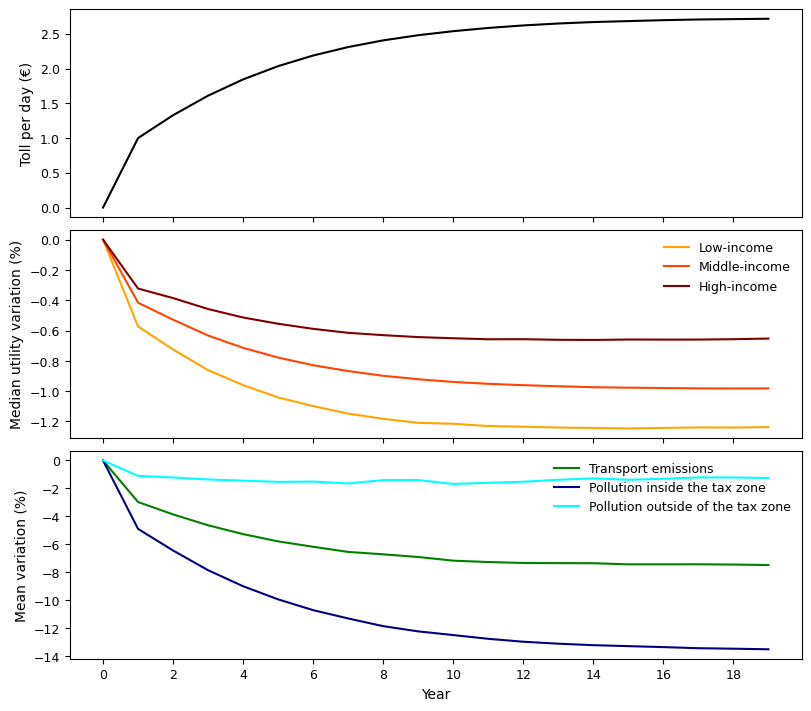

In [ ]:
emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high = relative_change_outputs(save_emissions, qol_in_zone, qol_out_zone, save_utility, compute_relative_change, compute_change_in_welfare, MAX_YEAR)

#Main results plot
main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high)

In [ ]:
save_tax

array([0.        , 0.5       , 0.66445554, 0.80519123, 0.92209168,
       1.01764821, 1.09401416, 1.15481137, 1.20293313, 1.24012265,
       1.26903936, 1.29226821, 1.31033886, 1.32432643, 1.33474337,
       1.34151405, 1.34834501, 1.35318214, 1.35588615, 1.35831692])

In [ ]:
emission_change

array([ 0.        , -2.97767819, -3.8629053 , -4.64387871, -5.27579381,
       -5.79744425, -6.18287589, -6.55202744, -6.72565386, -6.91499917,
       -7.17840132, -7.27642684, -7.34340109, -7.35512316, -7.36127586,
       -7.44169507, -7.44150238, -7.43758116, -7.45725385, -7.49402023])